### Summarize mean daily crude protein (CP) by pasture at CPER
Uses pre-processed daily CP rasters from Harmonized Landsat Sentinel (HLS - see Kearney et al. 2022) and Landsat-MODIS fusion (LMF). Computes the mean of all grid cells within each pasture. Returns a .csv file with a single CP value for each date for each pasture.

In [1]:
import os
os.environ['MKL_NUM_THREADS'] = '4'      # match threads_per_worker
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['OPENBLAS_NUM_THREADS'] = '4'
os.environ['LD_LIBRARY_PATH'] = '/project/cper_neon_aop/conda_envs/hls_nrt_env/lib'
import rioxarray as riox
import rasterio as rio
import xarray as xr
import re
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import datetime, timedelta
from hlsstack.hls_funcs.masks import shp2mask
from tqdm import tqdm
import glob
from hlsstack.utils.hpc_setup import launch_dask
import seaborn as sns

In [2]:
# dask cluster location
cluster_loc = 'local'

# path to HLS biomass data
hls_path = '/90daydata/cper_neon_aop/hls_nrt/cper/hls_cp/cper_hls_cp_{}.nc'
lmf_path = '/90daydata/cper_neon_aop/hls_nrt/cper/lmf_cp/cper_lmf_cp_{}.nc'

# the paths to shapefiles with CPER pasture boundaries
cper_2010_f = "../data/ground/boundaries/cper_pastures_2010_clip_edit.shp"
cper_2011_f = "../data/ground/boundaries/cper_pastures_2011_clip_edit.shp"
cper_2012_f = "../data/ground/boundaries/cper_pastures_2012_clip_edit.shp"
cper_2017_f = '../data/ground/boundaries/cper_pastures_2022_w_exclosures_spk.shp'

# the range of years to be processed
yrs = range(2000, 2026)
# drop 2012 since it could not be processed by LMF
yrs = [x for x in yrs if x != 2012]

hls_yrs = list(np.arange(2015, 2026))
lmf_yrs = [x for x in np.arange(2000, 2015) if x != 2012]

# the output path for the csv file
out_f = './outputs/cper_pasture_cp_2000_2025.csv'

In [3]:
past_list = ['10S', '11N', '11', '11S', '15E', '17N', '17S', '18S', '19E', '19N',
             '19NW', '19SE', '19SW', '1E', '1W', '20N', '20S', '20SE', '23E', '23W', 
             '24', '24SE', '24SW', '24W', '25', '25E', '25SE', '25W', '26E', '26W',
             '30NW', '31E', '31W', '32W', '5E', '6EW', '6W', '7NW', '7SW', '8E', '8NE', '8NW', '8SE']
#past_list = ['1W', '6W']

In [4]:
# whether to overwrite all existing complete years
overwrite_complete_yrs = True

# whether to overwrite incomplete years (or simply append new data)
overwrite_incomplete_yrs = True

# whether to get standard deviations in addition to means
get_std = True

In [5]:
# setup the dask cluster
if cluster_loc == 'local':
    #os.chdir(wkDIR)
    print('   setting up Local cluster...')
    from dask.distributed import LocalCluster, Client
    import dask
    cluster = LocalCluster(n_workers=8, threads_per_worker=2)
    client = Client(cluster)
    display(client)
elif cluster_loc == 'hpc':
    import psutil
    interface_prefs = [
        'ibp175s0',
        'ibp59s0',
        'enp24s0f0',
        'ens7f0',
        'ibp24s0',
        'ib0'
    ]
    interface = [x for x in interface_prefs if x in list(psutil.net_if_addrs().keys())][0]
    if len(interface) == 0:
        print('ERROR: Preferred interfaces not found on node!')
    else:
        print(interface)
    num_jobs=32
    client = launch_dask(cluster_loc=cluster_loc,
                         num_jobs=num_jobs,
                         mem_gb_per=4.0,
                         partition='atlas', 
                         duration='02:00:00',
                         slurm_opts={'interface': interface},
                         extra_directives=["--account=cper_neon_aop"],
                         wait_timeout=300,
                         debug=False)
    display(client)

   setting up Local cluster...


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 16,Total memory: 360.28 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38283,Workers: 8
Dashboard: http://127.0.0.1:8787/status,Total threads: 16
Started: Just now,Total memory: 360.28 GiB
Comm: tcp://127.0.0.1:42405,Total threads: 2
Dashboard: http://127.0.0.1:42541/status,Memory: 45.04 GiB
Nanny: tcp://127.0.0.1:37253,


In [6]:
# load and preprare any existing output data
if os.path.exists(out_f):
    if not overwrite_complete_yrs:
        df_out = pd.read_csv(out_f, parse_dates=['date'])
        if overwrite_incomplete_yrs:
            max_yday = df_out.groupby(df_out['Year'])['date'].max().dt.dayofyear
            drop_yrs = max_yday[max_yday < 365].index.values
            if len(drop_yrs) > 0:
                print('Dropping incomplete years:')
                print(drop_yrs)
                df_out = df_out[~df_out['Year'].isin(drop_yrs)].copy()
    else:
        df_out = None
else:
    df_out = None

In [7]:
if get_std:
    out_f_std = re.sub('.csv', '_std.csv', out_f)
    if os.path.exists(out_f_std):
        if not overwrite_complete_yrs:
            df_out_std = pd.read_csv(out_f_std, parse_dates=['date'])
            if overwrite_incomplete_yrs:
                max_yday = df_out_std.groupby(df_out_std['Year'])['date'].max().dt.dayofyear
                drop_yrs = max_yday[max_yday < 365].index.values
                if len(drop_yrs) > 0:
                    print('Dropping incomplete years:')
                    print(drop_yrs)
                    df_out_std = df_out_std[~df_out_std['Year'].isin(drop_yrs)].copy()
        else:
            df_out_std = None
    else:
        df_out_std = None

In [8]:
# loop through each year and extract pasture biomass means for each date
for idx, yr in enumerate(tqdm(yrs)):
    if df_out is not None:
        if yr in df_out['Year'].unique():
            skip_yr = True
        else:
            skip_yr = False
    else:
        skip_yr = False
    if skip_yr:
        continue
    else:
        # prepare the pasture boundaries to be converted into an xarray mask
        if yr <= 2010:
            cper_f = cper_2010_f
        elif yr == 2011:
            cper_f = cper_2011_f
        elif yr == 2012:
            cper_f = cper_2012_f
        else:
            cper_f = cper_2017_f
        cper = gpd.read_file(cper_f).to_crs(32613)
        cper = cper.rename(columns={'Past_Name_': 'Pasture',
                                    'PAST_NEW': 'Pasture'})
        cper = cper.dissolve('Pasture').reset_index()
        cper['Pasture'] = cper['Pasture'].str.upper()
        cper = cper[cper['Pasture'].isin(past_list)]
        cper_info = cper[['Pasture', 'geometry']].reset_index(drop=True).reset_index().rename(columns={'index': 'id'})
        past_dict = {row.id+1: row.Pasture for _, row in cper_info.iterrows()}
        past_dict[0] = 'UNK'
        cper_mask_shp = [(row.geometry, row.id+1) for _, row in cper_info.iterrows()]
        
        # define the file path
        if yr in hls_yrs:
            fpath = hls_path.format(str(yr))
            ds = riox.open_rasterio(fpath, masked=True)
            dat_source = 'HLS'
            # reproject if necessary
            if ds.rio.crs == None:
                ds = ds.rio.write_crs(3857)
        elif yr in lmf_yrs:
            fpath = lmf_path.format(str(yr))
            ds = xr.open_dataset(fpath)
            dat_source = 'LMF'
        if type(ds) == xr.core.dataarray.DataArray:
            ds = ds.to_dataset()
        # reproject if necessary
        if ds.rio.crs == None:
            ds = ds.rio.write_crs(cper.crs)
        elif ds.rio.crs != cper.crs:
            ds = ds.rio.reproject(cper.crs)
        if 'band' in ds.coords:
            # convert the band coordinate to date
            ds['band'] = [datetime(yr, 1, 1) + timedelta(days=int(x)) for x in ds['band'].values]
            # rename band coordinate to date
            ds = ds.rename({'band': 'date'})
        if 'time' in ds.coords:
            # rename band coordinate to date
            ds = ds.rename({'time': 'date'})
        if 'NDVI' in ds.variables:
            ds = ds.rename_vars({'NDVI': 'CP'})
        ds = ds.transpose('date', 'y', 'x')
        # create the pasture mask from shapefile
        cper_mask = shp2mask(shp=cper_mask_shp, 
                             transform=ds.rio.transform(), 
                             outshape=ds['CP'].shape[1:], 
                             xr_object=ds['CP'])
        # convert from numeric id's to pasture names
        past_mask = np.array([past_dict[i] for i in cper_mask.values.flatten()]).reshape(cper_mask.shape)
        # add the pasture mask to the biomass dataset
        ds = ds.assign(Pasture=(['y', 'x'], past_mask)).chunk({'y': 50, 'x': 50})
        ds = ds.set_coords('Pasture')
        # get pasture means and convert to dataframe
        df_yr = ds.groupby(
            ds['Pasture']).mean(
            dim='stacked_y_x').to_dataframe().reset_index().drop(
            columns='spatial_ref')
        df_yr['Year'] = yr
        #df_yr = df_yr.rename(columns={'Biomass': 'Biomass_kg_ha'})
        # add the data source to the output dataframe
        df_yr['Source'] = dat_source
        df_yr = df_yr[df_yr['Pasture'] != 'UNK']
        # create the initial output dataframe if it doesn't exist
        if df_out is None:
            df_out = df_yr.copy()
        # append to the existing output dataframe
        else:
            df_out = pd.concat([df_out, df_yr])

        if get_std:
            # get pasture standard_deviation and convert to dataframe
            df_yr_std = ds.groupby(
                ds['Pasture']).std(
                dim='stacked_y_x').to_dataframe().reset_index().drop(
                columns='spatial_ref')
            df_yr_std['Year'] = yr
            df_yr_std = df_yr_std.rename(columns={'CP': 'CP_std'})
            # add the data source to the output dataframe
            df_yr_std['Source'] = dat_source
            df_yr_std = df_yr_std[df_yr_std['Pasture'] != 'UNK']
            # create the initial output dataframe if it doesn't exist
            if df_out_std is None:
                df_out_std = df_yr_std.copy()
            # append to the existing output dataframe
            else:
                df_out_std = pd.concat([df_out_std, df_yr_std])

  0%|          | 0/25 [00:00<?, ?it/s]/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/project/cper_neon_aop/conda_envs/hls_nrt_env/lib/python3.9/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/project/cper_neon_aop/conda_env

In [9]:
from rasterio.plot import show
import matplotlib.pyplot as plt

In [10]:
#ds = riox.open_rasterio(fpath, masked=True)

In [17]:
ds.rio.transform()

Affine(30.000240753425924, 0.0, 517551.96950932156,
       0.0, -30.000240753425924, 4524434.404887154)

In [18]:
df_out['date'] = pd.to_datetime(df_out['date'].apply(lambda x: x.isoformat()))

In [19]:
df_out['Year'] = df_out['date'].dt.year
df_out = df_out.drop(columns=['YEAR'])

In [20]:
# preview the output dataframe
df_out

,date,Pasture,CP,Year,Source
0,2000-02-24,10S,NaN,2000,LMF
1,2000-02-24,11N,NaN,2000,LMF
2,2000-02-24,11S,NaN,2000,LMF
3,2000-02-24,15E,NaN,2000,LMF
4,2000-02-24,17N,NaN,2000,LMF
...,...,...,...,...,...
9484,2025-12-31,6EW,6.142947,2025,HLS
9485,2025-12-31,7NW,6.210801,2025,HLS
9486,2025-12-31,8E,6.274670,2025,HLS
9487,2025-12-31,8NW,6.259439,2025,HLS


In [21]:
df_out = df_out.sort_values(['Pasture', 'Year', 'date']).reset_index()

In [22]:
# quality control check that all pastures are present for each year
df_out.groupby('Year').apply(lambda x: len(x['Pasture'].unique()))

Year
2000    30
2001    30
2002    30
2003    30
2004    30
2005    30
2006    30
2007    30
2008    30
2009    30
2010    30
2011    30
2013    25
2014    25
2015    25
2016    25
2017    25
2018    25
2019    25
2020    25
2021    25
2022    25
2023    25
2024    25
2025    25
dtype: int64

In [23]:
pasts_plot = ['19N', '15E', '5E', '10S']
months_plot = np.arange(1, 13)

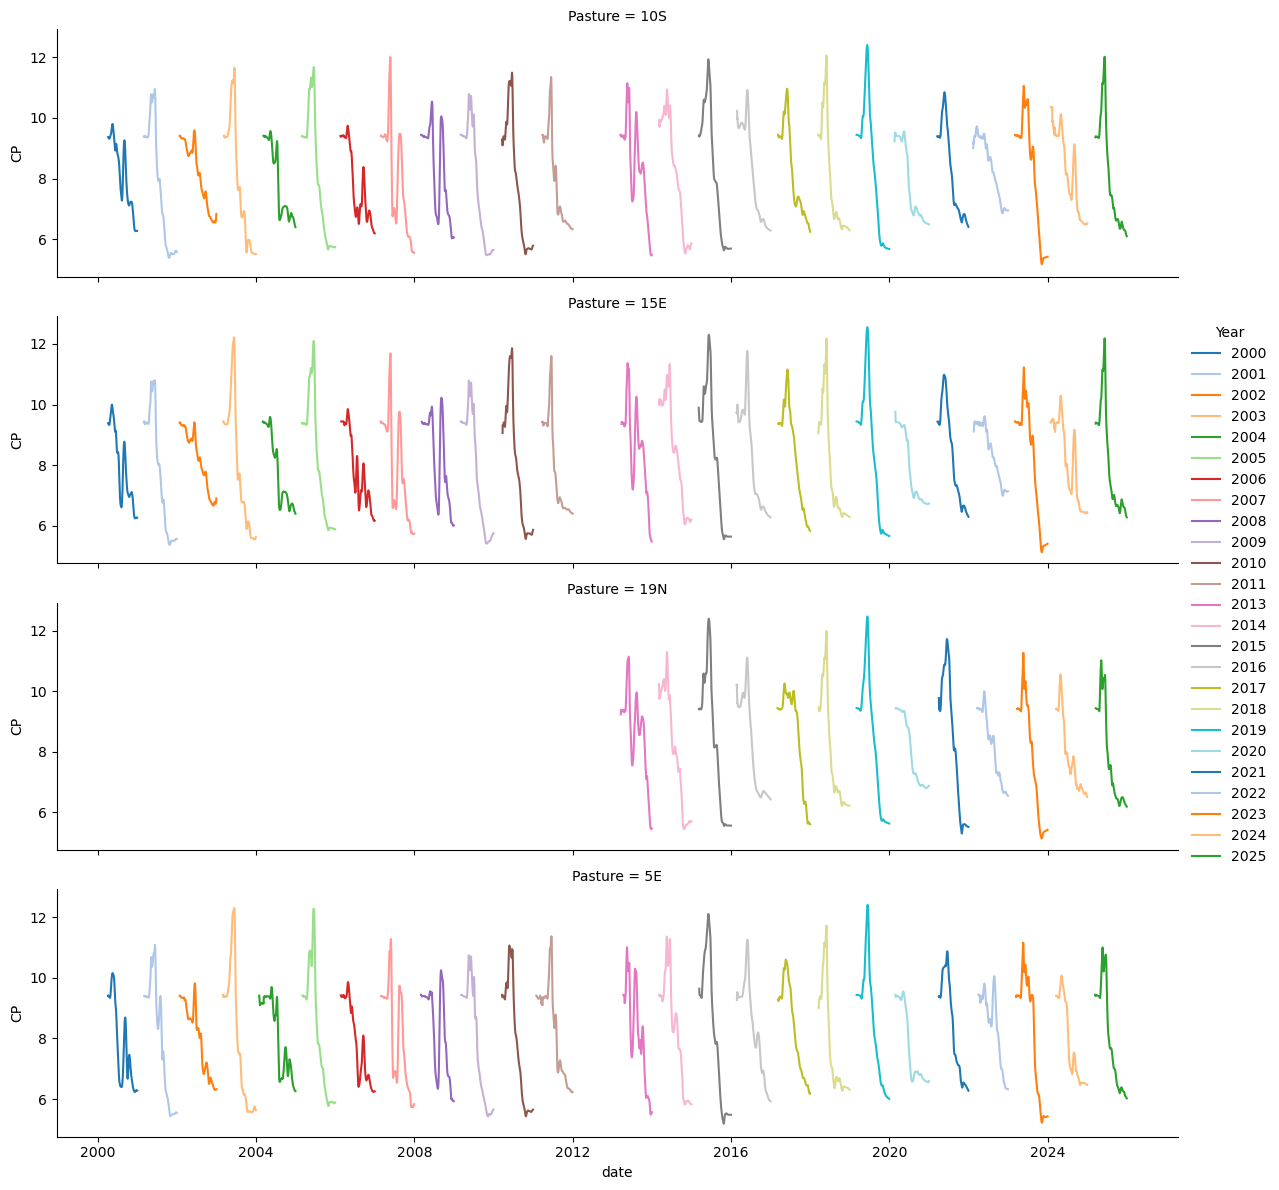

In [24]:
# plot all pastures and all dates on a single figure
sns.relplot(data=df_out[df_out['Pasture'].isin(pasts_plot) & 
            df_out['date'].dt.month.isin(months_plot)],
            x='date', y='CP', 
            row='Pasture',
            hue='Year', palette='tab20',
            kind="line", errorbar=None,
            height=3, aspect=4)

In [25]:
# write the output dataframe to disk
df_out.to_csv(out_f, index=False)

In [26]:
if get_std:
    df_out_std['date'] = pd.to_datetime(df_out_std['date'].apply(lambda x: x.isoformat()))
    
    df_out_std['Year'] = df_out_std['date'].dt.year
    df_out_std = df_out_std.drop(columns=['YEAR'])
    
    df_out_std = df_out_std.sort_values(['Pasture', 'Year', 'date'])
    
    # quality control check that all pastures are present for each year
    print(df_out_std.groupby('Year').apply(lambda x: len(x['Pasture'].unique())))

    # write the output dataframe to disk
    df_out_std.to_csv(out_f_std, index=False)

Year
2000    30
2001    30
2002    30
2003    30
2004    30
2005    30
2006    30
2007    30
2008    30
2009    30
2010    30
2011    30
2013    25
2014    25
2015    25
2016    25
2017    25
2018    25
2019    25
2020    25
2021    25
2022    25
2023    25
2024    25
2025    25
dtype: int64


#### Plot saved results

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

In [92]:
# read in the saved .csv output
df_saved = pd.read_csv(out_f, parse_dates=['date'])
#df_saved

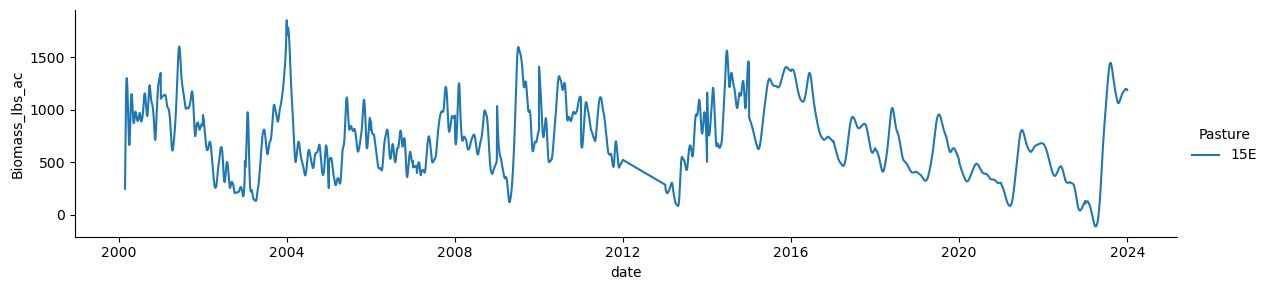

In [93]:
# plot all pastures and all dates on a single figure
sns.relplot(data=df_saved[df_saved['Pasture'] == '15E'], x='date', y='Biomass_lbs_ac', hue='Pasture', kind="line", errorbar=None,
            height=3, aspect=4)